In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Reshape, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import Input
import os

In [4]:
# Set dataset path
data_dir = r'D:\Project\data_kaggle\aug\train_split'

In [5]:
batch_size = 32
img_height = 224
img_width = 224
image_size = (img_height, img_width)
epochs = int(input("Enter epochs number: "))

Enter epochs number:  30


In [6]:
train_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb'  # Force RGB mode
)

Found 5863 images belonging to 8 classes.


In [7]:
val_datagen = ImageDataGenerator()

val_data = r"D:\Project\data_kaggle\aug\val_split"

val_generator = val_datagen.flow_from_directory(
    val_data,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
)

Found 1469 images belonging to 8 classes.


In [8]:
def transformer_encoder(inputs, num_heads, key_dim, ff_dim, dropout_rate=0.1):
    """Transformer Encoder Block"""
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout_rate)(x, x)
    x = Dropout(dropout_rate)(x)
    x = Add()([x, inputs])

    y = LayerNormalization(epsilon=1e-6)(x)
    y = Dense(ff_dim, activation='relu')(y)
    y = Dropout(dropout_rate)(y)
    y = Dense(inputs.shape[-1])(y)
    outputs = Add()([y, x])

    return outputs

def hybrid_model(input_shape, num_classes, num_transformer_blocks=1, num_heads=4, key_dim=128, ff_dim=256, dropout_rate=0.1):
    """Hybrid Model: ResNet-50 as CNN + Transformer"""
    inputs = Input(shape=input_shape)

    # ResNet-50 as Feature Extractor (Pretrained on ImageNet)
    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)
    base_model.trainable = False  # Freeze ResNet layers

    # Extract CNN Features
    cnn_output = base_model.output
    x = GlobalAveragePooling2D()(cnn_output)

    # Reshape for Transformer Processing
    x = Reshape((-1, x.shape[-1]))(x)

    # Apply Transformer Blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, num_heads, key_dim, ff_dim, dropout_rate)

    # Classification Head
    x = GlobalAveragePooling2D()(cnn_output)  # Ensure compatibility with Dense layer
    x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

input_shape = (224, 224, 3)
num_classes = len(train_generator.class_indices)

model = hybrid_model(input_shape, num_classes)

In [9]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 230, 230, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 112, 112, 64) 9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 112, 112, 64) 256         conv1_conv[0][0]                 
______________________________________________________________________________________________

In [10]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [11]:
# Train the model
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)

Epoch 1/30
184/184 [==============================] - 79s 327ms/step - loss: 0.7573 - accuracy: 0.8736 - val_loss: 0.4237 - val_accuracy: 0.9687
Epoch 2/30
184/184 [==============================] - 47s 252ms/step - loss: 0.3959 - accuracy: 0.9632 - val_loss: 0.2998 - val_accuracy: 0.9877
Epoch 3/30
184/184 [==============================] - 47s 252ms/step - loss: 0.3112 - accuracy: 0.9742 - val_loss: 0.2433 - val_accuracy: 0.9912
Epoch 4/30
184/184 [==============================] - 47s 252ms/step - loss: 0.2624 - accuracy: 0.9777 - val_loss: 0.2230 - val_accuracy: 0.9884
Epoch 5/30
184/184 [==============================] - 45s 243ms/step - loss: 0.2419 - accuracy: 0.9773 - val_loss: 0.1892 - val_accuracy: 0.9932
Epoch 6/30
184/184 [==============================] - 47s 254ms/step - loss: 0.2209 - accuracy: 0.9773 - val_loss: 0.2006 - val_accuracy: 0.9843
Epoch 7/30
184/184 [==============================] - 47s 251ms/step - loss: 0.2154 - accuracy: 0.9785 - val_loss: 0.1696 - val_ac

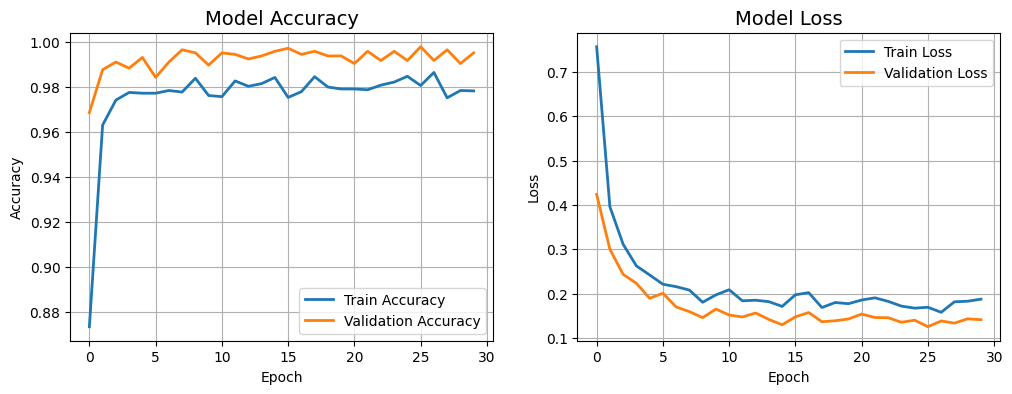

In [12]:
# Plot accuracy and loss curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [13]:
# Evaluate model
test_data = r'D:\Project\data_kaggle\test'

eval_generator = train_datagen.flow_from_directory(
    test_data,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

y_true = eval_generator.classes
y_pred = model.predict(eval_generator)

# Convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)  # Fix tf.argmax issue

Found 190 images belonging to 8 classes.


In [14]:
from sklearn.metrics import classification_report, confusion_matrix


# Print classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred_classes))

# Plot confusion matrix
conf_mat = confusion_matrix(y_true, y_pred_classes)
class_labels = list(train_generator.class_indices.keys())


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        25
           3       1.00      1.00      1.00        23
           4       0.88      1.00      0.93        21
           5       1.00      1.00      1.00        23
           6       1.00      1.00      1.00        26
           7       1.00      0.87      0.93        23

    accuracy                           0.98       190
   macro avg       0.98      0.98      0.98       190
weighted avg       0.99      0.98      0.98       190



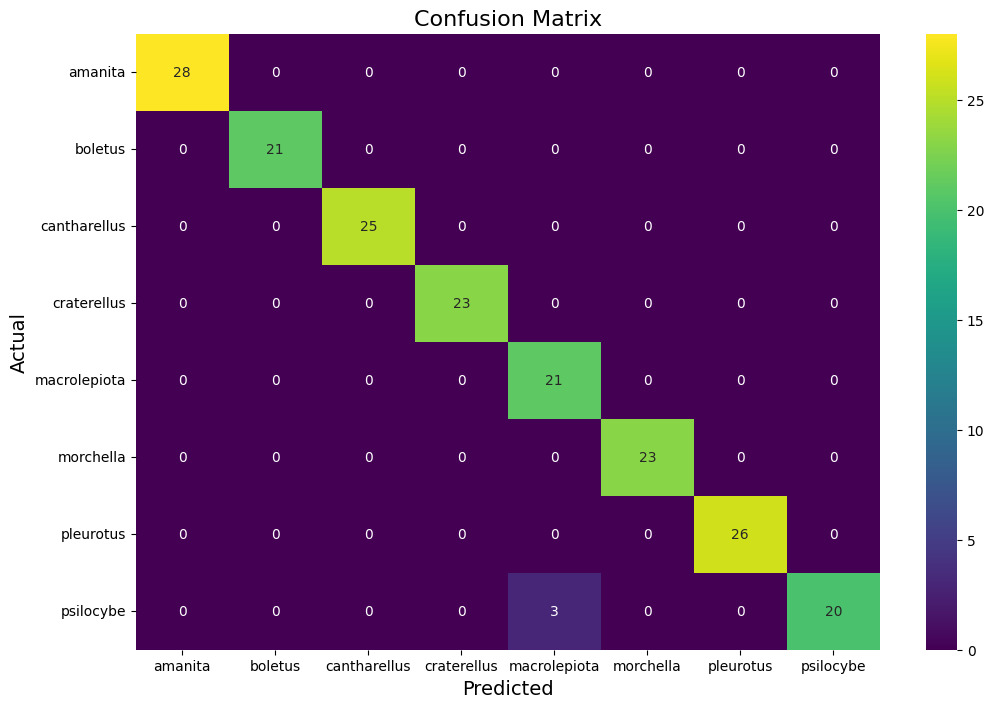

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="viridis", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.show()

In [16]:
model_version = epochs
next_version = str(int(model_version) + 10)

In [17]:
import shutil

notebook_filename = f"CNN_{model_version}_ADAM.ipynb"
new_notebook_filename = f"CNN_{next_version}_ADAM.ipynb"

shutil.copy(notebook_filename, new_notebook_filename)
print(f"Notebook copied as {new_notebook_filename}")

Notebook copied as CNN_40_ADAM.ipynb


In [ ]:
os._exit(00)